# EDA on Retail Sales Data

# import libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("Retail_sales.csv")
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


## Initial Data Inspection

### 1.Dataset Shape

In [25]:
df.shape

(2000, 11)

### 2.Dataset Information

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transactions_id  2000 non-null   int64  
 1   sale_date        2000 non-null   object 
 2   sale_time        2000 non-null   object 
 3   customer_id      2000 non-null   int64  
 4   gender           2000 non-null   object 
 5   age              1990 non-null   float64
 6   category         2000 non-null   object 
 7   quantiy          1997 non-null   float64
 8   price_per_unit   1997 non-null   float64
 9   cogs             1997 non-null   float64
 10  total_sale       1997 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 172.0+ KB


### 3.Missing Value Check

In [27]:
df.isnull().sum()

transactions_id     0
sale_date           0
sale_time           0
customer_id         0
gender              0
age                10
category            0
quantiy             3
price_per_unit      3
cogs                3
total_sale          3
dtype: int64

### 4.Statistical Summary

In [28]:
df.describe()

,transactions_id,customer_id,age,quantiy,price_per_unit,cogs,total_sale
count,2000.000000,2000.000000,1990.000000,1997.000000,1997.000000,1997.000000,1997.000000
mean,1000.500000,66.341500,41.343216,2.512769,180.117677,95.023886,456.544817
std,577.494589,44.937185,13.668167,1.132708,189.685225,121.898695,560.101381
min,1.000000,1.000000,18.000000,1.000000,25.000000,6.250000,25.000000
25%,500.750000,24.000000,29.000000,1.000000,30.000000,13.000000,60.000000
50%,1000.500000,69.000000,42.000000,3.000000,50.000000,27.500000,150.000000
75%,1500.250000,102.000000,53.000000,4.000000,300.000000,147.000000,900.000000
max,2000.000000,155.000000,64.000000,4.000000,500.000000,620.000000,2000.000000


## Descriptive Statistics

### 1.Mean

In [29]:
df.select_dtypes(include='number').mean()

transactions_id    1000.500000
customer_id          66.341500
age                  41.343216
quantiy               2.512769
price_per_unit      180.117677
cogs                 95.023886
total_sale          456.544817
dtype: float64

### 2.Median

In [30]:
df.select_dtypes(include='number').median()

transactions_id    1000.5
customer_id          69.0
age                  42.0
quantiy               3.0
price_per_unit       50.0
cogs                 27.5
total_sale          150.0
dtype: float64

### 3.Mode

In [31]:
df.select_dtypes(include='number').mode().iloc[0]

transactions_id     1.0
customer_id         1.0
age                43.0
quantiy             4.0
price_per_unit     50.0
cogs               13.5
total_sale         50.0
Name: 0, dtype: float64

### 4.Standard Deviation

In [32]:
df.select_dtypes(include='number').std()

transactions_id    577.494589
customer_id         44.937185
age                 13.668167
quantiy              1.132708
price_per_unit     189.685225
cogs               121.898695
total_sale         560.101381
dtype: float64

## Time Series Analysis

In [33]:
# Convert sale_date to datetime format
df['sale_date'] = pd.to_datetime(df['sale_date'])

# Create month and quarter columns
df['month'] = df['sale_date'].dt.to_period('M').astype(str)
df['quarter'] = df['sale_date'].dt.to_period('Q').astype(str)

# Monthly sales
monthly_sales = df.groupby('month')['total_sale'].sum()

# Quarterly sales
quarterly_sales = df.groupby('quarter')['total_sale'].sum()

### 1.Monthly Sales Trend

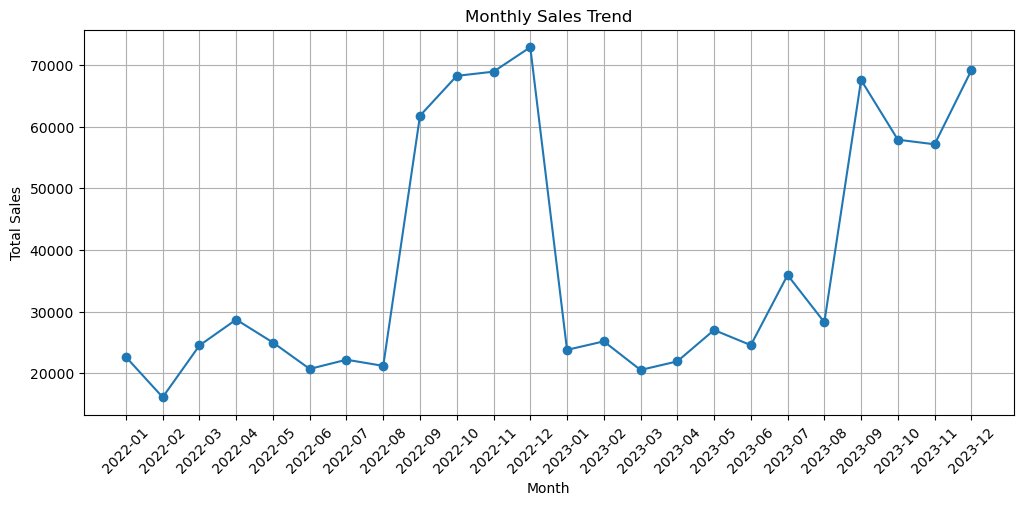

In [34]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### 2.Quarterly Sales Trend

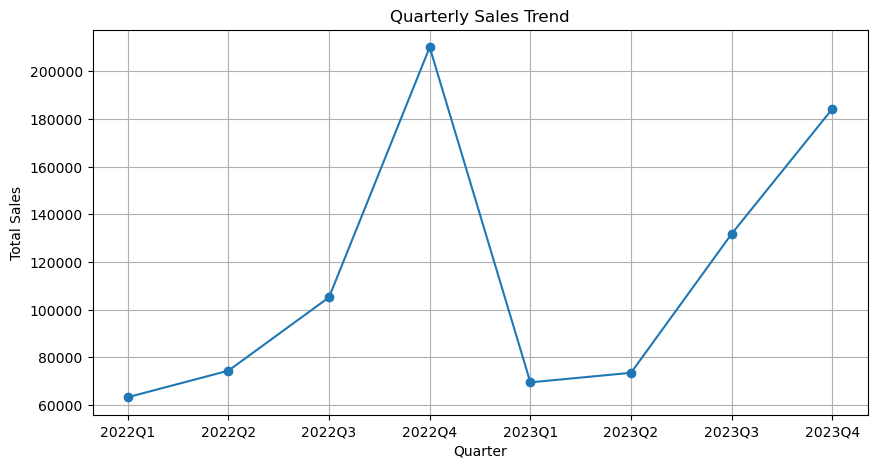

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.grid(True)

plt.show()

### Observation: The quarterly sales trend provides a broader view of sales performance and helps identify the best-performing quarters.

## Customer Demographics Analysis

### 1.Age Group Distribution

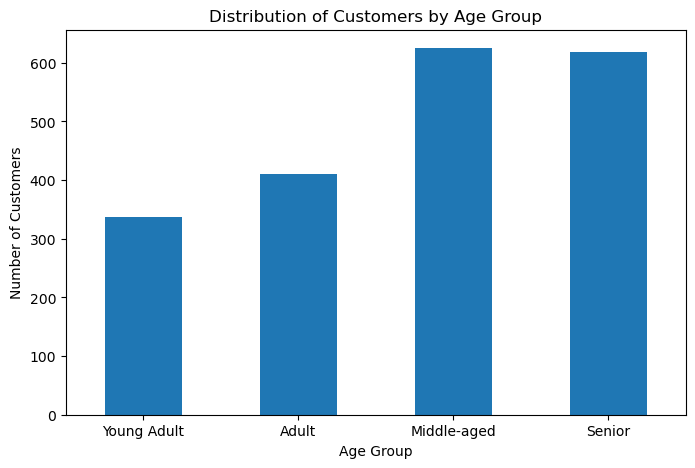

In [36]:
# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 50, 65],
    labels=['Young Adult', 'Adult', 'Middle-aged', 'Senior']
)

# Count customers in each age group
age_group_counts = df['age_group'].value_counts().sort_index()

# Plot age group distribution
plt.figure(figsize=(8, 5))

age_group_counts.plot(kind='bar')

plt.title('Distribution of Customers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)
plt.show()

### **Observation:** The age group distribution shows the number of customers belonging to different age categories. This helps identify the dominant customer age group and understand the target customer base.

### 2.Gender Breakdown

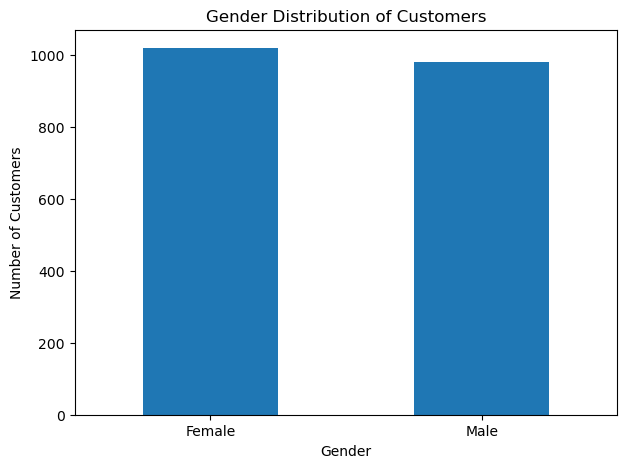

In [37]:
# Count customers by gender
gender_counts = df['gender'].value_counts()

# Plot gender distribution
plt.figure(figsize=(7, 5))

gender_counts.plot(kind='bar')

plt.title('Gender Distribution of Customers')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)
plt.show()

### **Observation:** The gender breakdown shows the distribution of male and female customers. This insight can help businesses understand their customer composition and plan targeted marketing strategies.

## Time Series Analysis

#### This section analyzes monthly and quarterly sales trends to identify changes in sales performance over time.

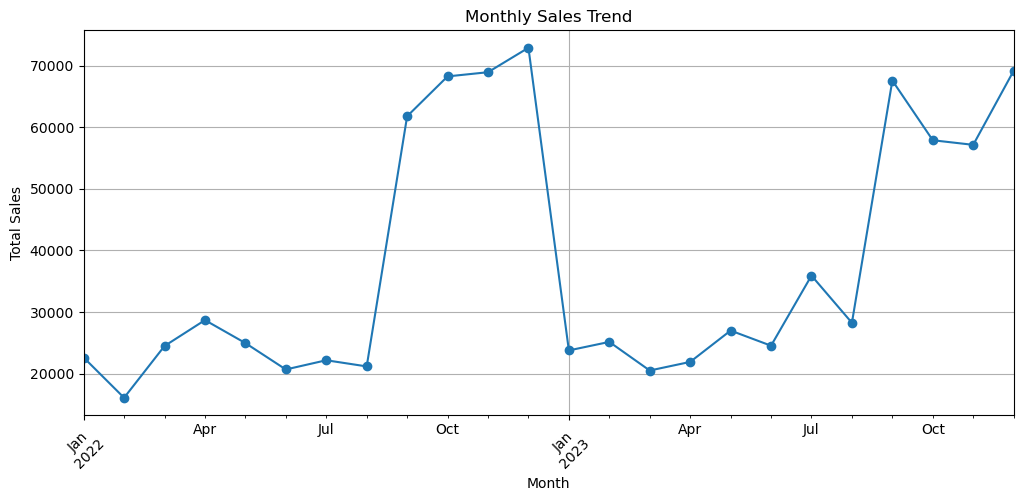

In [38]:
# Convert sale_date to datetime format
df['sale_date'] = pd.to_datetime(df['sale_date'])

# Create monthly sales
monthly_sales = df.groupby(df['sale_date'].dt.to_period('M'))['total_sale'].sum()

# Plot monthly sales trend
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### **Observation:** The monthly sales trend shows how total sales changed over time. Peaks indicate months with higher sales performance, while dips represent relatively lower sales periods.

### 1.Quarterly Sales Code

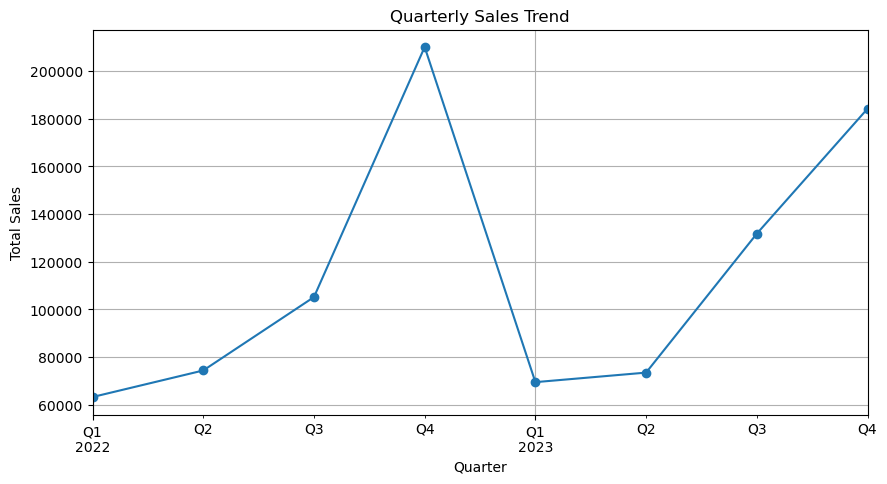

In [39]:
# Create quarterly sales
quarterly_sales = df.groupby(df['sale_date'].dt.to_period('Q'))['total_sale'].sum()

# Plot quarterly sales trend
plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind='line', marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

### **Observation:** The quarterly sales analysis provides a broader view of sales performance and helps identify the strongest and weakest quarters.

## Customer Demographics Analysis

### This section analyzes customer age groups and gender distribution to understand the demographic profile of customers.

### 1.Age Group Distribution

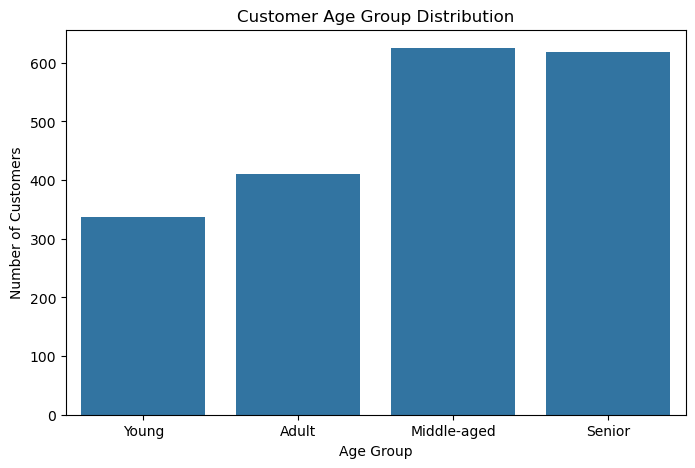

In [40]:
# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 50, 100],
    labels=['Young', 'Adult', 'Middle-aged', 'Senior']
)

# Plot age group distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='age_group')
plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

### **Observation:** The age group distribution shows which customer age segment contributes the highest number of transactions.

### 2.Gender Breakdown

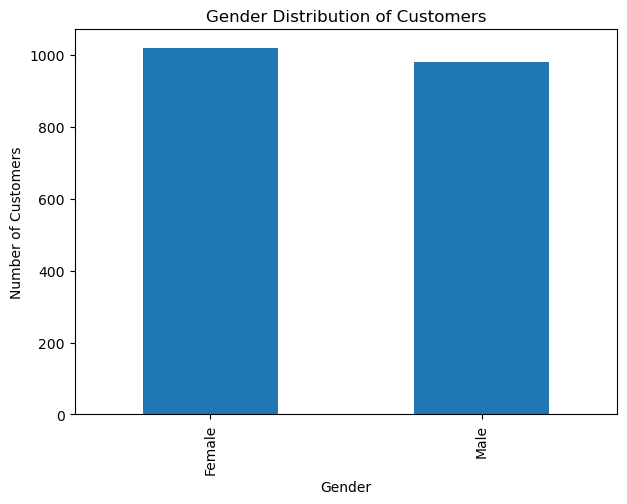

In [41]:
# Gender distribution
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(7, 5))
gender_counts.plot(kind='bar')
plt.title('Gender Distribution of Customers')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

### **Observation:** The gender distribution shows the contribution of different genders to the overall customer transactions.

### 3.Revenue by Category

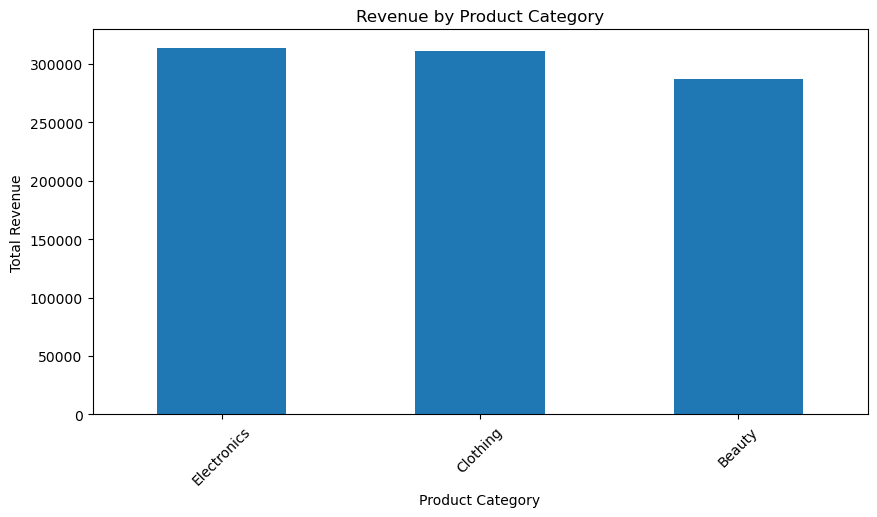

In [42]:
# Revenue by product category
category_revenue = df.groupby('category')['total_sale'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
category_revenue.plot(kind='bar')
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### **Observation:** The revenue analysis shows which product categories generate the highest total sales and contribute most to the business revenue.

## Correlation Analysis

#### This section analyzes the relationship between numerical variables using a correlation matrix.

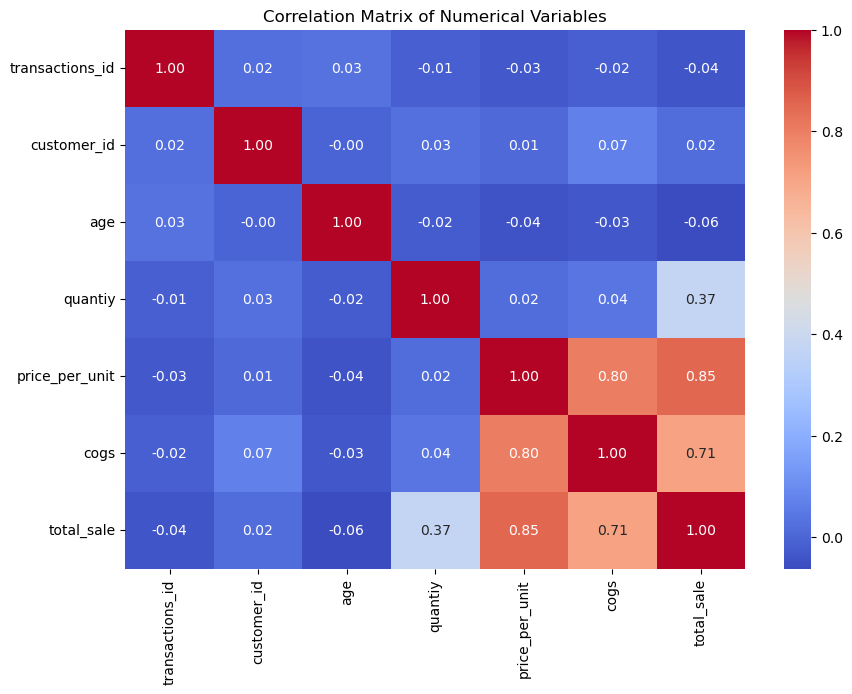

In [43]:
# Select numerical columns
numerical_data = df.select_dtypes(include='number')

# Calculate correlation matrix
correlation_matrix = numerical_data.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### **Observation:** The correlation heatmap shows the strength and direction of relationships between numerical variables. Values closer to +1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values near 0 indicate a weak relationship.

## Additional Visualization

### Total Sales by Gender

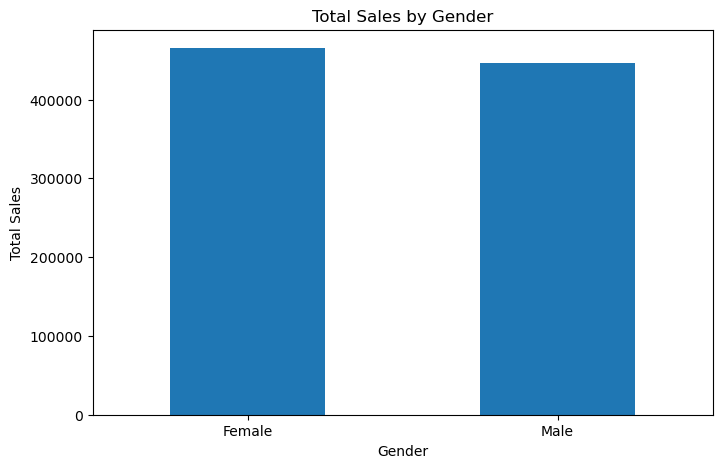

In [44]:
# Calculate total sales by gender
gender_sales = df.groupby('gender')['total_sale'].sum().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(8, 5))

gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)
plt.show()

### **Observation:** This visualization compares total sales generated by different genders. It reveals which customer group contributes more to overall revenue, helping businesses design more targeted marketing strategies.

## Conclusion and Business Recommendations

Based on the exploratory data analysis, the following actionable recommendations can help improve business performance:

1. **Focus marketing efforts on the highest-performing customer segments:** 
   The business should target the dominant age group and gender segment with personalized promotions, advertisements, and loyalty offers.

2. **Increase inventory and promotional activities for high-performing categories:**
   Categories generating the highest sales revenue should receive priority in inventory planning and marketing campaigns to maximize revenue.

3. **Use sales trends for better planning:**
   Monthly and quarterly sales trends should be monitored to identify high-demand periods. The business can increase inventory and launch targeted offers before peak sales periods.

4. **Use customer and sales insights for targeted campaigns:**
   Customer demographics and sales patterns should be regularly analyzed to create data-driven marketing strategies and improve customer engagement.